In [2]:
import numpy as np
import matplotlib.pyplot as plt

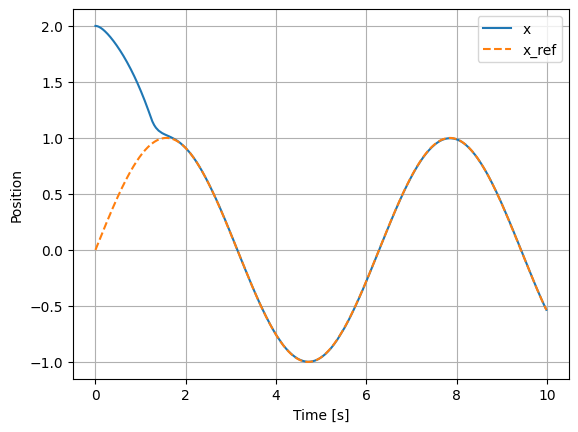

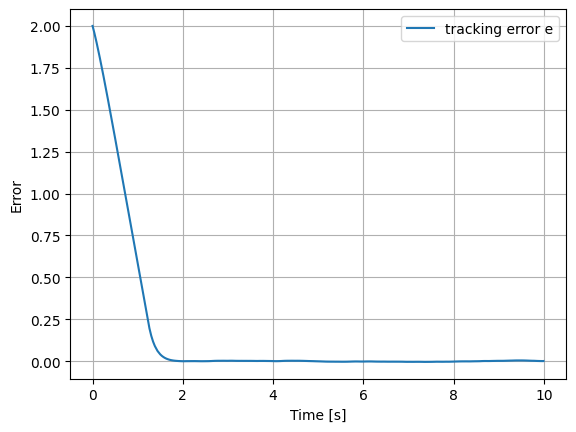

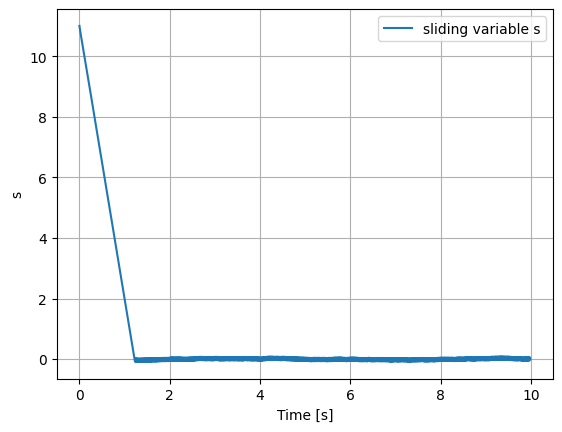

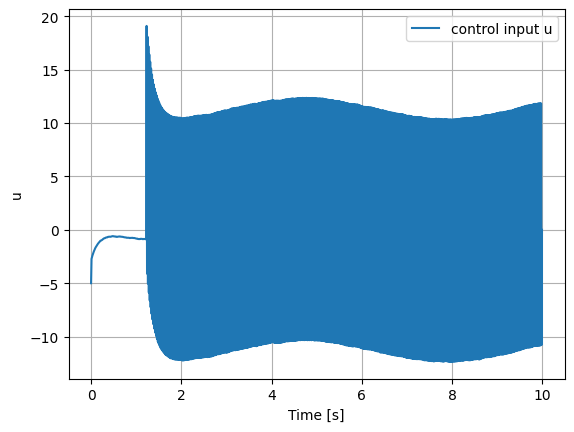

In [3]:
# Settings
dt = 0.01
T = 10.0
t = np.arange(0, T, dt)

# Controller gains
lam = 6.0
k1 = 10.0
k2 = 1.0

# Boundary layer to reduce chattering
eps = 0.02

def sat(x, eps):
    return np.clip(x / eps, -1.0, 1.0)

# Reference trajectory
def x_ref(t):
    return np.sin(t)

def dx_ref(t):
    return np.cos(t)

def ddx_ref(t):
    return -np.sin(t)

# States
x = np.zeros_like(t)
dx = np.zeros_like(t)

# Initial conditions
x[0] = 2.0
dx[0] = 0.0

s_arr = np.zeros_like(t)
u_arr = np.zeros_like(t)

s_prev = 0.0

noise_std = 0.2
noise = np.random.normal(0.0, noise_std, size=t.shape)

# Simulation
for i in range(len(t) - 1):
    # Tracking errors
    e = x[i] - x_ref(t[i])
    de = dx[i] - dx_ref(t[i])

    # Sliding variable
    s = de + lam * e

    # Numerical derivative of s
    ds = (s - s_prev) / dt
    s_prev = s

    # Twisting control part
    #u_twist = -k1 * sat(s, eps) - k2 * sat(ds, eps)
    u_twist = -k1 * np.sign(s) - k2 * np.sign(ds)

    # Equivalent/feedforward part
    u = ddx_ref(t[i]) - lam * de + u_twist

    # Double integrator dynamics
    ddx = u + noise[i]

    dx[i + 1] = dx[i] + ddx * dt
    x[i + 1] = x[i] + dx[i] * dt

    s_arr[i] = s
    u_arr[i] = u

# ---------- Plot ----------
plt.figure()
plt.plot(t, x, label="x")
plt.plot(t, x_ref(t), "--", label="x_ref")
plt.xlabel("Time [s]")
plt.ylabel("Position")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(t, x - x_ref(t), label="tracking error e")
plt.xlabel("Time [s]")
plt.ylabel("Error")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(t, s_arr, label="sliding variable s")
plt.xlabel("Time [s]")
plt.ylabel("s")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(t, u_arr, label="control input u")
plt.xlabel("Time [s]")
plt.ylabel("u")
plt.grid(True)
plt.legend()
plt.show()